In [1]:
import os
import shutil
import time
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import EfficientNetB0
from keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from keras.models import Sequential
from keras.layers import Input, Flatten, Dense, Dropout
from keras import optimizers

#  Dataset download & split

In [12]:
import kagglehub

folder = 'data'
if os.path.exists(folder):
    shutil.rmtree(folder)
    os.makedirs(folder)
else:
    os.makedirs(folder)

path = kagglehub.dataset_download("ashikahmmed/uc-merce", output_dir=os.path.join(os.getcwd(), "data"))
source_dir = os.path.join('data', 'converted_uc_merced_data')
labels = [l for l in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, l))]
print(f"Classes found: {len(labels)}")

100%|██████████| 64.7M/64.7M [00:02<00:00, 30.2MB/s]


Extracting files...
Classes found: 21


# Few-shot split function

In [13]:
def create_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

def split_dataset_nshot(source_dir, labels, n_train, n_val=10, n_test=10, random_state=42):
    """
    Split dataset with exactly n_train images per class for training.
    val and test sets stay fixed at n_val/n_test images per class.
    """
    split_name = f'split_{n_train}shot'
    split_base = os.path.join(source_dir, split_name)

    for label in labels:
        src_path = os.path.join(source_dir, label)
        if not os.path.isdir(src_path):
            continue

        files = sorted([
            f for f in os.listdir(src_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))
        ])

        if len(files) < n_train + n_val + n_test:
            print(f"⚠️  {label}: not enough images ({len(files)}), skipping")
            continue

        # Fix test and val, vary train
        remaining, test_files = train_test_split(files, test_size=n_test, random_state=random_state)
        remaining, val_files = train_test_split(remaining, test_size=n_val, random_state=random_state)
        train_files = remaining[:n_train]  # take only n_train images

        for split, file_list in [('train', train_files), ('validate', val_files), ('test', test_files)]:
            dest = os.path.join(split_base, split, label)
            create_dir(dest)
            for f in file_list:
                shutil.copy(os.path.join(src_path, f), os.path.join(dest, f))

    print(f"✅ {n_train}-shot split complete → {split_base}")
    return split_base

#  Feature extraction & training pipeline

In [14]:
def extract_features(base, directory, batch_size=32):
    datagen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess)
    generator = datagen.flow_from_directory(directory, batch_size=batch_size, shuffle=False)
    class_names = generator.class_indices

    X_batches, Y_batches = [], []
    image_count = 0
    for X_batch, Y_batch in generator:
        X_batches.append(base.predict(X_batch, verbose=0))
        Y_batches.append(Y_batch)
        image_count += X_batch.shape[0]
        if image_count >= generator.n:
            break

    return np.concatenate(X_batches), np.concatenate(Y_batches), class_names


def train_nshot(n_train, source_dir, labels, epochs=20):
    print(f"\n{'='*50}")
    print(f"  {n_train}-SHOT EXPERIMENT")
    print(f"{'='*50}")

    split_base = split_dataset_nshot(source_dir, labels, n_train=n_train)
    train_dir = os.path.join(split_base, 'train')
    val_dir   = os.path.join(split_base, 'validate')
    test_dir  = os.path.join(split_base, 'test')

    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    base.trainable = False

    t0 = time.time()
    print("Extracting features...")
    X_train, Y_train, class_names = extract_features(base, train_dir)
    X_val,   Y_val,   _           = extract_features(base, val_dir)
    X_test,  Y_test,  _           = extract_features(base, test_dir)

    n_labels     = Y_train.shape[1]
    input_shape  = X_train.shape[1:]

    top_model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(n_labels, activation='softmax')
    ])

    top_model.compile(
        optimizer=optimizers.Adam(learning_rate=2e-5),
        loss='categorical_crossentropy',
        metrics=['acc']
    )

    history = top_model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_val, Y_val),
        verbose=1
    )

    elapsed = time.time() - t0
    test_loss, test_acc = top_model.evaluate(X_test, Y_test, verbose=0)
    print(f"⏱ Time: {elapsed:.1f}s | Test accuracy: {test_acc:.2%} | Test loss: {test_loss:.4f}")

    return {
        'base': base,
        'top_model': top_model,
        'history': history,
        'class_names': class_names,
        'test_acc': test_acc,
        'test_dir': test_dir,
        'train_time': elapsed
    }

# Run each shot
*Be carefull this may be long depending on your computer*

In [15]:
source_dir = os.path.join('data', 'converted_uc_merced_data')
labels = os.listdir(source_dir)
shot_results = {}

for n in [10, 30, 50, 80]:
    shot_results[n] = train_nshot(n, source_dir, labels)


  10-SHOT EXPERIMENT
✅ 10-shot split complete → data\converted_uc_merced_data\split_10shot
Extracting features...
Found 210 images belonging to 21 classes.
Found 210 images belonging to 21 classes.
Found 210 images belonging to 21 classes.
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - acc: 0.0857 - loss: 3.4891 - val_acc: 0.2810 - val_loss: 2.6688
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - acc: 0.6190 - loss: 1.4347 - val_acc: 0.4476 - val_loss: 2.0522
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - acc: 0.9000 - loss: 0.5621 - val_acc: 0.5095 - val_loss: 1.7159
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - acc: 0.9810 - loss: 0.2455 - val_acc: 0.5333 - val_loss: 1.5299
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - acc: 1.0000 - loss: 0.1224 - val_acc: 0.5476 - val_loss: 1.4249
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - acc: 1.0000 - loss: 0.0846 - val_acc: 0.5571 - val_loss: 1.3612
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - acc: 1.0000

# Accuracy vs shots curve

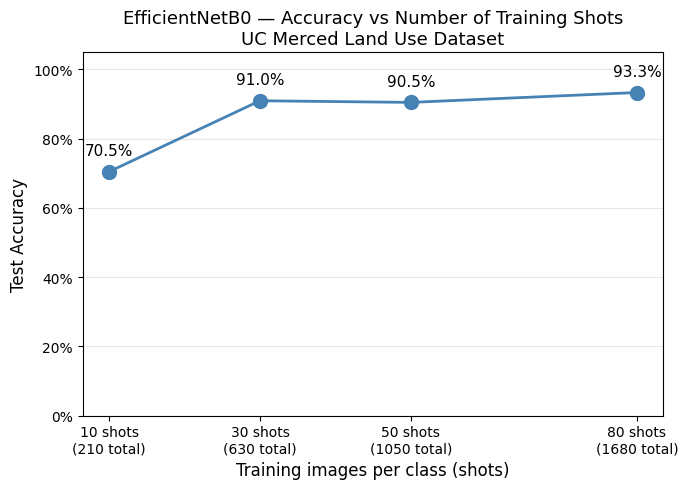


📊 Summary
Shots      Total imgs      Test Acc     Time (s)
---------------------------------------------
10         210             70.48%       41.1s
30         630             90.95%       90.9s
50         1050            90.48%       136.4s
80         1680            93.33%       207.5s


In [25]:
shot_sizes = sorted(shot_results.keys())
accuracies = [shot_results[n]['test_acc'] for n in shot_sizes]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(shot_sizes, accuracies, marker='o', linewidth=2, markersize=10, color='steelblue')

for x, y in zip(shot_sizes, accuracies):
    ax.annotate(f'{y:.1%}', (x, y), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=11)

ax.set_xlabel('Training images per class (shots)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('EfficientNetB0 — Accuracy vs Number of Training Shots\nUC Merced Land Use Dataset', fontsize=13)
ax.set_xticks(shot_sizes)
ax.set_xticklabels([f'{n} shots\n({n*21} total)' for n in shot_sizes])
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures//fewshot_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Summary")
print(f"{'Shots':<10} {'Total imgs':<15} {'Test Acc':<12} {'Time (s)'}")
print("-" * 45)
for n in shot_sizes:
    r = shot_results[n]
    print(f"{n:<10} {n*21:<15} {r['test_acc']:<12.2%} {r['train_time']:.1f}s")

# Grad-CAM comparison

In [ ]:
# Already present in train_vgg16_uc_merced
def make_gradcam_heatmap(img_array, conv_base, top_model, last_conv_layer_name='block5_conv3'):
    # Get the last conv layer from conv_base directly
    last_conv = conv_base.get_layer(last_conv_layer_name)
    feature_extractor = tf.keras.Model(
        inputs=conv_base.inputs,
        outputs=[last_conv.output, conv_base.output]
    )
    
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_output, features = feature_extractor(img_tensor)
        tape.watch(conv_output)

        predictions = top_model(features) 
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())


def overlay_gradcam(img_bgr, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (256, 256))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    superimposed = np.uint8(heatmap_colored * alpha + img_bgr * (1 - alpha))
    superimposed = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb, superimposed

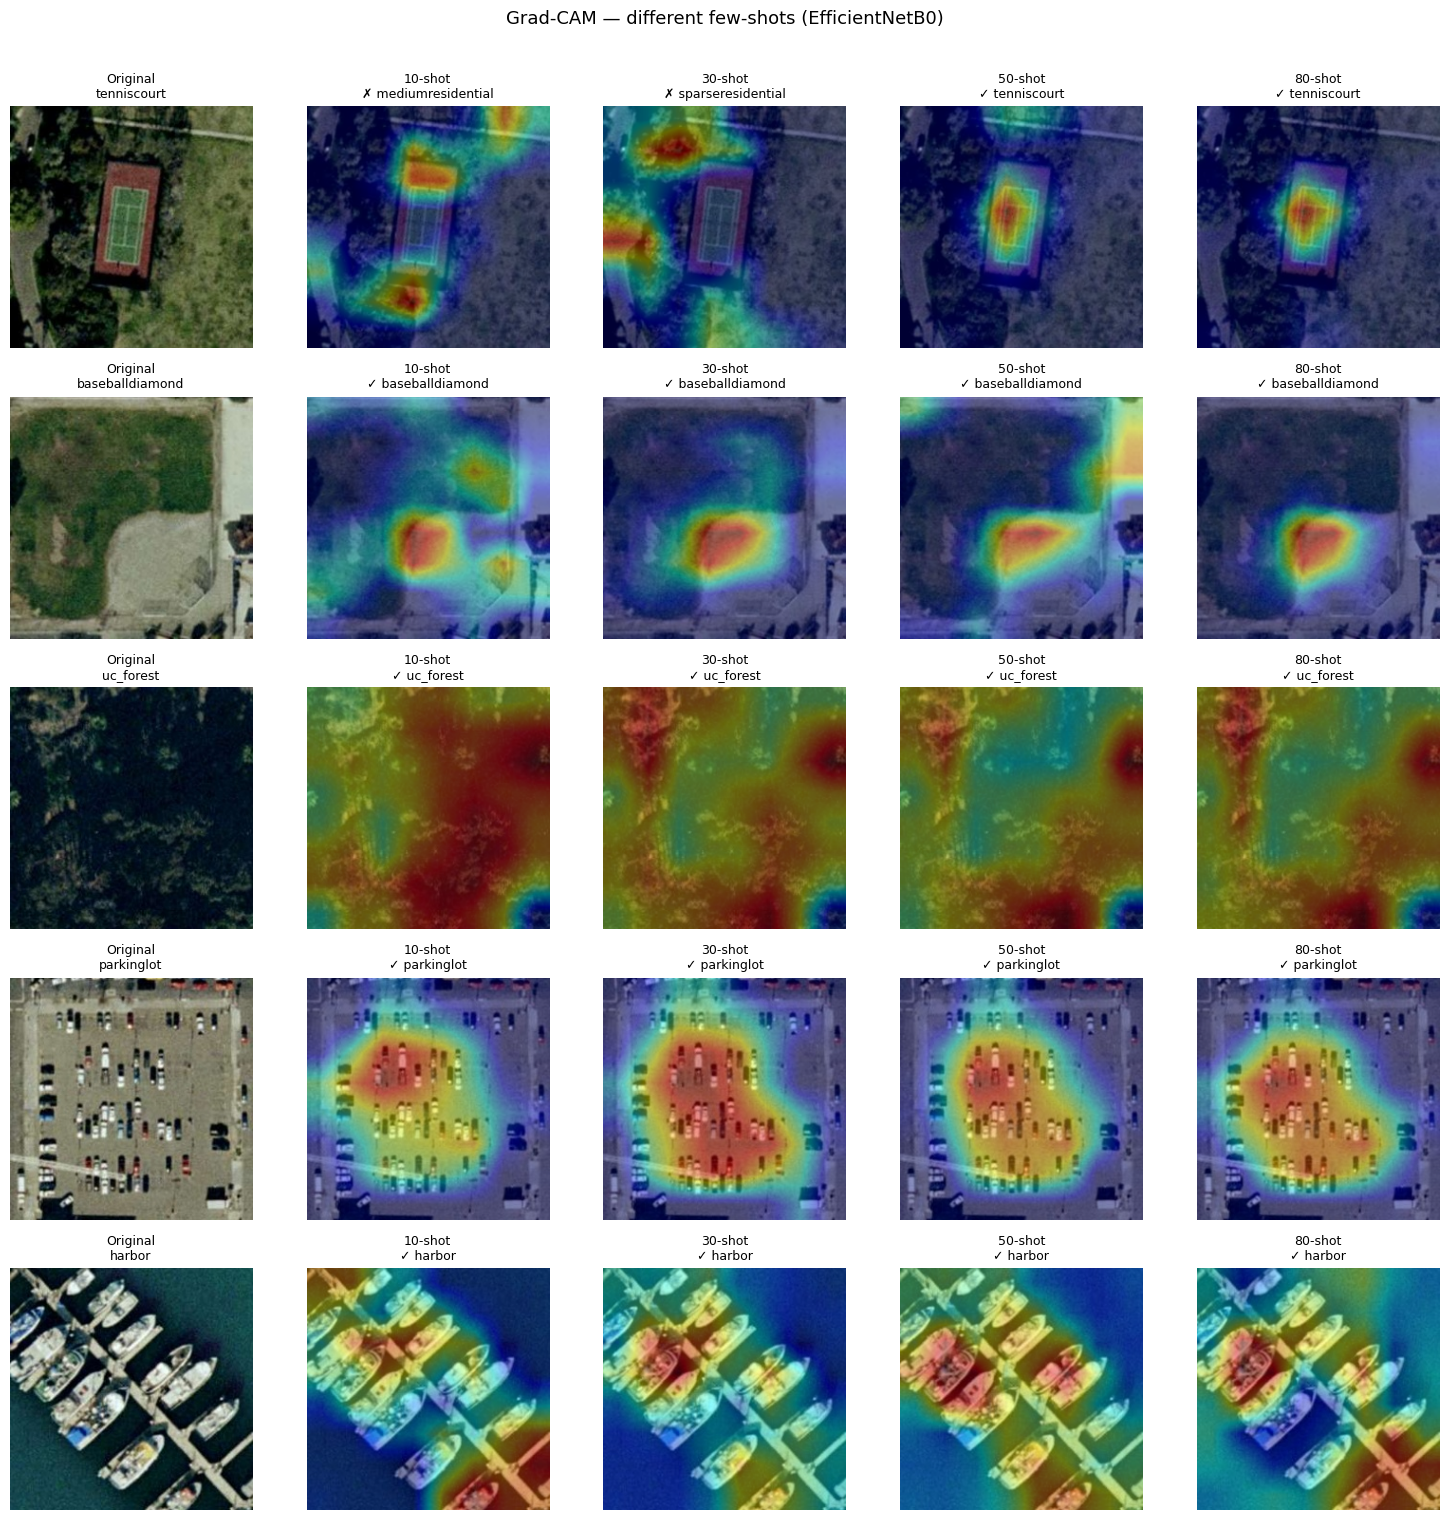

In [ ]:
preprocess_map_gradcam = {
    10: efficientnet_preprocess,
    30: efficientnet_preprocess,
    50: efficientnet_preprocess,
    80: efficientnet_preprocess
}

classes_to_viz = ['tenniscourt', 'baseballdiamond', 'uc_forest', 'parkinglot', 'harbor']

fig, axes = plt.subplots(len(classes_to_viz), 5, figsize=(15, 3 * len(classes_to_viz)))

for i, cls in enumerate(classes_to_viz):
    cls_dir = os.path.join(shot_results[80]['test_dir'], cls)
    img_file = sorted(os.listdir(cls_dir))[0]
    img_path = os.path.join(cls_dir, img_file)

    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (256, 256))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f'Original\n{cls}', fontsize=9)
    axes[i, 0].axis('off')

    for j, n in enumerate([10, 30, 50, 80]):
        img_array = efficientnet_preprocess(
            np.expand_dims(img_resized.astype('float32'), axis=0)
        )
        heatmap, pred_idx = make_gradcam_heatmap(
            img_array,
            shot_results[n]['base'],
            shot_results[n]['top_model'],
            last_conv_layer_name='top_activation'
        )
        _, superimposed = overlay_gradcam(img_resized, heatmap)

        class_list = list(shot_results[n]['class_names'].keys())
        pred_class = class_list[pred_idx]
        symbol = '✓' if pred_class == cls else '✗'

        axes[i, j+1].imshow(superimposed)
        axes[i, j+1].set_title(f'{n}-shot\n{symbol} {pred_class}', fontsize=9)
        axes[i, j+1].axis('off')

plt.suptitle('Grad-CAM — different few-shots (EfficientNetB0)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures//gradcam_fewshot.png', dpi=150, bbox_inches='tight')
plt.show()